In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.preprocessing import StandardScaler


In [2]:
import os
print(os.getcwd())


w:\Predictive-Maintenance-FactoryGuard-AI\notebooks


In [3]:
df = pd.read_csv("../data/cleaned_data.csv")

df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)


In [6]:
scaler = StandardScaler()

X_train_numeric = X_train.drop(columns=['Product ID', 'Type'])
X_test_numeric = X_test.drop(columns=['Product ID', 'Type'])

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [7]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [8]:
from sklearn.metrics import accuracy_score, precision_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nF1 Score:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Confusion Matrix:
[[1961    0]
 [   2   37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1961
           1       1.00      0.95      0.97        39

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000


F1 Score: 0.9736842105263158
Recall: 0.9487179487179487
Accuracy: 0.999
Precision: 1.0


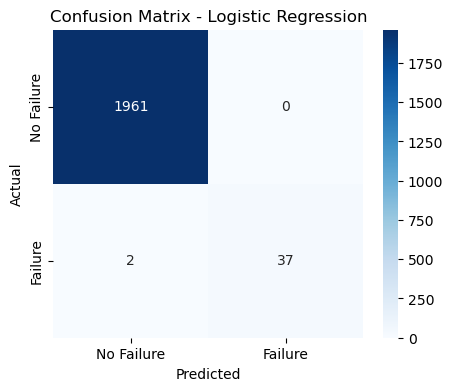

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


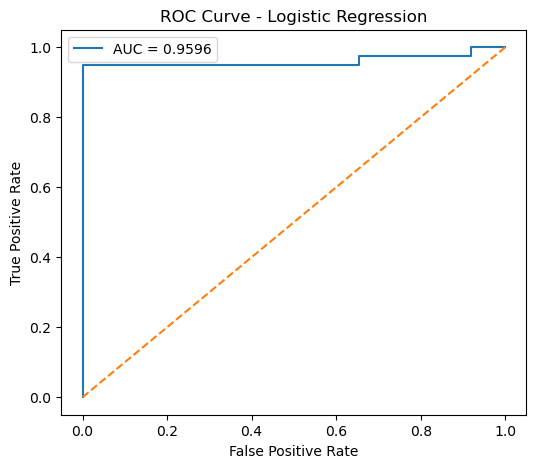

In [10]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


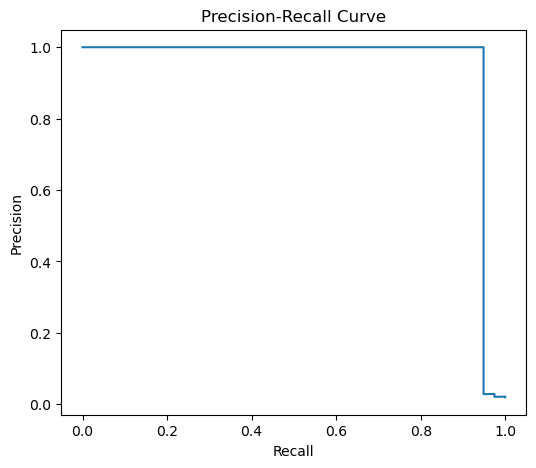

In [11]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_numeric, y_train)

y_pred_rf = rf_model.predict(X_test_numeric)


In [13]:
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nF1 Score (RF):", f1_score(y_test, y_pred_rf))
print("Recall (RF):", recall_score(y_test, y_pred_rf))
print("Accuracy (RF):", accuracy_score(y_test, y_pred_rf))
print("Precision (RF):", precision_score(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
[[1961    0]
 [   2   37]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1961
           1       1.00      0.95      0.97        39

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000


F1 Score (RF): 0.9736842105263158
Recall (RF): 0.9487179487179487
Accuracy (RF): 0.999
Precision (RF): 1.0


In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ]
})

results

,Model,F1 Score,Recall
0,Logistic Regression,0.973684,0.948718
1,Random Forest,0.973684,0.948718


In [15]:
import joblib
joblib.dump(rf_model, "model.pkl")
print("Model saved successfully")


Model saved successfully
